# 01 · Exploratory Data Analysis — SLM vs LLM for Key Information Extraction

**Dissertation:** *Can Small Language Models (SLMs) match Large Language Models (LLMs) for
Key Information Extraction (KIE) from financial documents?*

This notebook explores the **two datasets** that drive the whole study and shows **how the
data's shape motivated every major design decision** (the field schemas, the `max_input_lines`
cap, the strict field-level metric, and the recall-focused Phase-3 work).

| Dataset | Role | Documents | Fields | Difficulty |
|---|---|---|---|---|
| **SROIE** | Simple receipts | short, clean | **4** (`company, date, address, total`) | easy — projector-friendly |
| **Kleister-Charity** | UK charity financial reports | long, multi-page | **8** (name, number, dates, £ income/spend, address parts) | hard — where the SLM↔LLM gap widens |

Everything below reads the **same normalised records** the evaluation harness consumes
(`src/data/loaders.py`), so the numbers here are exactly the data the models see.


## 0 · Setup
Bootstrap the repo path (works both from `notebooks/` and the repo root, and on Colab after `git clone`), then import the project's own data layer.

In [1]:
import sys, os
from pathlib import Path

# Find the repo root: the nearest ancestor containing both `src/` and `config/`.
here = Path.cwd()
REPO = next((p for p in [here, *here.parents] if (p / "src").is_dir() and (p / "config").is_dir()), here)
sys.path.insert(0, str(REPO))
print("repo root:", REPO)

import json, re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_config, load_schema, schema_field_names
from src.data.loaders import load_dataset, available_datasets
from src.data.preprocess import from_dataset_record

pd.set_option("display.max_colwidth", 90)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

cfg = load_config()
print("datasets present:", available_datasets(cfg))

repo root: /Users/azharali/Desktop/Projects/slm-llm/slm-vs-llm-kie


datasets present: ['sroie', 'kleister_charity']


## 1 · Load the raw records

Each dataset ships as a normalised JSONL (`data/raw/<dataset>/<split>.jsonl`), one record per
document. We load **both splits** — `test` is the frozen benchmark; `train` is the pool the
few-shot examples and (in Phase 3) the QLoRA fine-tuning are drawn from.

In [2]:
DATASETS = ["sroie", "kleister_charity"]
raw = {ds: {sp: load_dataset(cfg, ds, split=sp) for sp in ("train", "test")} for ds in DATASETS}

split_tbl = pd.DataFrame(
    [{"dataset": ds, "train_docs": len(raw[ds]["train"]), "test_docs": len(raw[ds]["test"])}
     for ds in DATASETS]
).set_index("dataset")
split_tbl.loc["TOTAL"] = split_tbl.sum()
split_tbl

,train_docs,test_docs
dataset,,
sroie,501,125
kleister_charity,1729,440
TOTAL,2230,565


> **Why a train/test split matters here.** Phase-3 fine-tuning (QLoRA) and few-shot examples
> use the **train** split *only*. The 20-doc **test** benchmark must never leak into training,
> or the headline "fine-tuned SLM beats the LLM" result would be worthless. The code enforces
> this separation (`few_shot_pool` / `build_test_set`).

## 2 · The target schemas — what the models must extract

The schema is the ground truth of the task: the exact field names, their types, and whether
they're required. **Field `type` drives the metric's normalisation** — a `date` match ignores
format (`21-05-17` == `2017-05-21`), a `currency` match ignores the `£`/`,` (`£1,234.00` ==
`1234`). This is why we score *semantically*, not by string equality.

In [3]:
def schema_table(ds):
    sc = load_schema(cfg, ds)
    return pd.DataFrame(sc["fields"])[["name", "type", "required"]]

for ds in DATASETS:
    print(f"\n=== {ds} — {len(load_schema(cfg, ds)['fields'])} fields ===")
    display(schema_table(ds))


=== sroie — 4 fields ===


,name,type,required
0,company,string,True
1,date,date,True
2,address,string,True
3,total,currency,True



=== kleister_charity — 8 fields ===


,name,type,required
0,charity_name,string,True
1,charity_number,string,False
2,report_date,date,False
3,income_annually_in_british_pounds,currency,False
4,spending_annually_in_british_pounds,currency,False
5,address__post_town,string,False
6,address__postcode,string,False
7,address__street_line,string,False


## 3 · The frozen 20-document test set

The whole benchmark runs on a **fixed, seeded** selection of 20 documents (10 SROIE + 10
Kleister). Fixing it means every model — and every Phase-3 improvement — is measured on the
*identical* inputs, so a before/after delta is a fair comparison and not sampling noise.

In [4]:
from src.data.gt import load_test_set
sel = load_test_set(cfg)
sel_df = pd.DataFrame(sel["doc_ids"])
print(f"seed={sel['seed']}  count={sel['count']}  datasets={sel['datasets_used']}")
sel_df.groupby("dataset").size().rename("docs_in_benchmark").to_frame()

seed=42  count=20  datasets=['kleister_charity', 'sroie']


,docs_in_benchmark
dataset,
kleister_charity,10
sroie,10


## 4 · How a document is structured

The two datasets carry OCR differently, and the pipeline normalises both into the **same**
"simple JSON" shape (`lines`, `key_values`, `tables`) via `from_dataset_record` — the exact
representation the prompt is built from.

- **SROIE** ships **word-level boxes** (`words` with `bbox`) → the pipeline reconstructs reading-order **lines**.
- **Kleister** ships pre-segmented **lines** already.

Let's look at one of each.

In [5]:
def peek(ds, split="test", i=0):
    rec = raw[ds][split][i]
    sj = from_dataset_record(rec)
    print(f"[{ds}] doc_id={rec['doc_id']}  raw_keys={list(rec.keys())}")
    print(f"  n_lines={len(sj['lines'])}  n_key_values={len(sj['key_values'])}")
    print("  first 8 lines:")
    for ln in sj["lines"][:8]:
        print("    |", ln[:80])
    print("  GOLD:", json.dumps(rec.get("gold", {}), ensure_ascii=False)[:400])

peek("sroie", i=0)
print("\n" + "-"*80)
peek("kleister_charity", i=0)

[sroie] doc_id=262  raw_keys=['doc_id', 'dataset', 'schema_name', 'split', 'page', 'words', 'key_values', 'tables', 'gold']
  n_lines=17  n_key_values=0
  first 8 lines:
    | POSTED
    | 99 SPEED MART S/B (519537-X)
    | LOT P.T. 2811, JALAN ANGSA,
    | TAMAN BERKELEY
    | 41150 KLANG, SELANGOR
    | 1032-SUBANG PERDANA
    | GST ID. NO : 000181747712
    | INVOICE NO : 18039/103/T0209
  GOLD: {"company": "99 SPEED MART S/B", "date": "21-05-17", "address": "LOT P.T. 2811, JALAN ANGSA, TAMAN BERKELEY 41150 KLANG, SELANGOR 1032-SUBANG PERDANA", "total": "20.80"}

--------------------------------------------------------------------------------
[kleister_charity] doc_id=1ada336f29e8247f9f55a8d7e1b1c0da.pdf  raw_keys=['doc_id', 'dataset', 'schema_name', 'split', 'page', 'lines', 'key_values', 'tables', 'gold']
  n_lines=85  n_key_values=0
  first 8 lines:
    | Trustees’ annual report (including Directors’ report) for the period
    | From: 1st August 2017 Period start date To: 31st Ju

## 5 · Document length — the case for `max_input_lines: 120`

Small local models have small context windows and limited working memory (running on an 8 GB
M1). If we fed a 300-line charity report verbatim, tiny models would truncate mid-document or
blow their context. The distribution below is **why the config caps prompts at 120 lines** —
it covers the vast majority of receipts fully while bounding the long Kleister tail.

In [6]:
len_rows = []
for ds in DATASETS:
    for sp in ("train", "test"):
        for rec in raw[ds][sp]:
            n = len(from_dataset_record(rec)["lines"])
            len_rows.append({"dataset": ds, "split": sp, "n_lines": n})
len_df = pd.DataFrame(len_rows)
(len_df.groupby("dataset")["n_lines"]
       .describe(percentiles=[0.5, 0.9])[["count", "mean", "50%", "90%", "max"]]
       .round(1))

,count,mean,50%,90%,max
dataset,,,,,
kleister_charity,2169.0,166.2,159.0,250.0,250.0
sroie,626.0,29.1,28.0,37.0,59.0


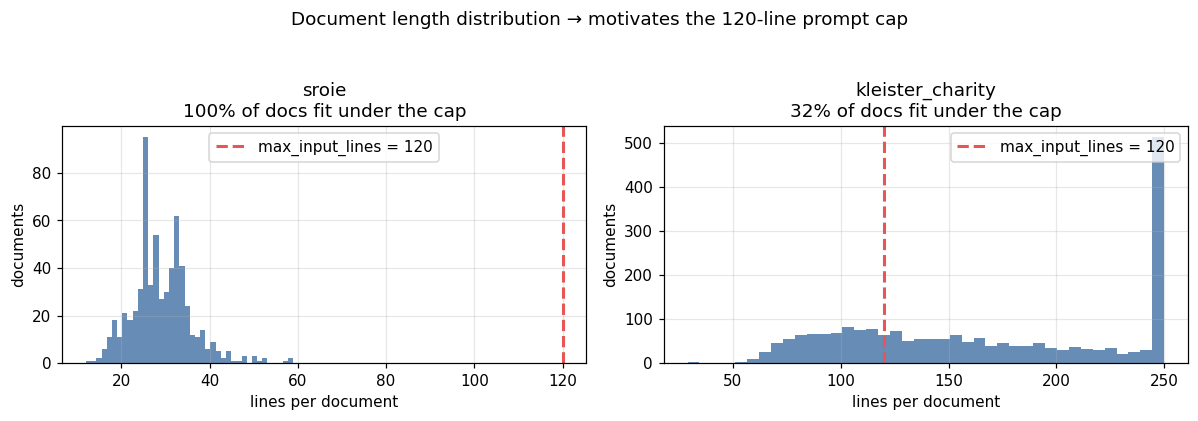

In [7]:
CAP = cfg["conditions"]["max_input_lines"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, ds in zip(axes, DATASETS):
    vals = len_df.loc[len_df.dataset == ds, "n_lines"]
    ax.hist(vals.clip(upper=400), bins=40, color="#4C78A8", alpha=0.85)
    ax.axvline(CAP, color="#E45756", lw=2, ls="--", label=f"max_input_lines = {CAP}")
    pct = (vals <= CAP).mean() * 100
    ax.set_title(f"{ds}\n{pct:.0f}% of docs fit under the cap")
    ax.set_xlabel("lines per document"); ax.set_ylabel("documents"); ax.legend()
fig.suptitle("Document length distribution → motivates the 120-line prompt cap", y=1.05, fontsize=12)
plt.tight_layout(); plt.show()

## 6 · Field presence (fill rate) — the case for a **recall**-aware study

A field can only be extracted if it's actually *present* in the document. Required fields
(like `charity_name`) appear almost always; optional financial fields (income, spending,
street address) are frequently absent even in the gold data. This matters two ways:

1. It sets the **ceiling** — a model can't be penalised for a field the gold itself lacks
   (the metric scores those as correct "both empty").
2. The fields that *are* present but hard to locate in a long report are exactly where
   **recall** (missed fields) — not hallucination — becomes the bottleneck. This is the
   finding that motivates the Phase-3 regex-fallback work.

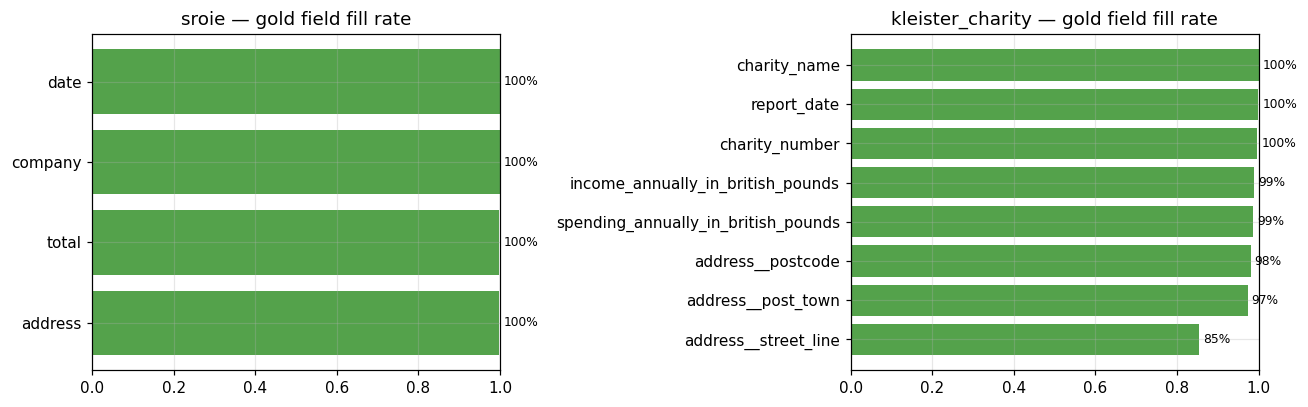

In [8]:
def fill_rates(ds):
    fields = schema_field_names(load_schema(cfg, ds))
    recs = raw[ds]["train"] + raw[ds]["test"]
    n = len(recs)
    def present(v):
        return v is not None and str(v).strip().lower() not in {"", "null", "none", "n/a", "-"}
    return pd.Series(
        {f: sum(present(r.get("gold", {}).get(f)) for r in recs) / n for f in fields},
        name="fill_rate",
    ).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, ds in zip(axes, DATASETS):
    fr = fill_rates(ds)
    colors = ["#54A24B" if v >= 0.8 else "#F58518" if v >= 0.4 else "#E45756" for v in fr]
    ax.barh(fr.index, fr.values, color=colors)
    ax.set_xlim(0, 1); ax.set_title(f"{ds} — gold field fill rate")
    for y, v in enumerate(fr.values):
        ax.text(v + 0.01, y, f"{v:.0%}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

## 7 · Value characteristics — the case for **type-aware** normalisation

The same fact is written many ways across documents. If we scored by exact string match, a
model would be marked wrong for `£1,234.00` vs `1234`, or `21 May 2017` vs `2017-05-21`.
The metric normalises by field *type* instead. Below: the raw variety the normaliser has to
absorb.

In [9]:
# SROIE `total` (currency) and `date` — show the raw formats the normaliser must fold together.
sroie = raw["sroie"]["train"] + raw["sroie"]["test"]
totals = [str(r["gold"].get("total")) for r in sroie if r["gold"].get("total")]
dates  = [str(r["gold"].get("date"))  for r in sroie if r["gold"].get("date")]

def date_shape(s):
    return re.sub(r"\d", "9", s.strip())

print("sample raw TOTAL values:", totals[:8])
print("distinct DATE surface formats (top 6):")
for shape, c in Counter(date_shape(d) for d in dates).most_common(6):
    print(f"   {shape:<14} x{c}")

sample raw TOTAL values: ['635.00', '45.35', '28.90', '12.00', '87.10', '31.32', '28.50', '67.85']
distinct DATE surface formats (top 6):
   99/99/9999     x330
   99-99-99       x82
   99-99-9999     x70
   99/99/99       x61
   99 MAR 9999    x14
   99 MAY 9999    x13


## 8 · Few-shot pool availability

Few-shot prompting (`few_shot_k=2`) draws its examples from the **train** split. This confirms
both datasets have ample disjoint examples to sample from without touching the test set —
and, in Phase 3, thousands of Kleister train docs to fine-tune on.

In [10]:
pool = pd.DataFrame(
    [{"dataset": ds,
      "train_pool": len(raw[ds]["train"]),
      "few_shot_k": cfg["conditions"]["few_shot_k"],
      "enough_for_fewshot": len(raw[ds]["train"]) >= cfg["conditions"]["few_shot_k"]}
     for ds in DATASETS]
).set_index("dataset")
pool

,train_pool,few_shot_k,enough_for_fewshot
dataset,,,
sroie,501,2,True
kleister_charity,1729,2,True


## 9 · Key takeaways → design decisions

The EDA directly justifies the study's setup:

| Observation | Design decision it drives |
|---|---|
| Kleister docs have a long line-count tail | **`max_input_lines: 120`** — bound context for small models & API cost |
| Same value, many surface forms (dates, £) | **Type-aware normalisation** in the metric (date/currency/string) |
| Many optional fields are genuinely absent | Metric scores "both-empty" as correct; **recall** measured separately |
| Present-but-hard fields dominate the loss | **Phase-3 [P4] regex fallback** targets missed fields (recall) |
| Large train pool, disjoint from test | Safe **few-shot (k=2)** and **Phase-3 QLoRA** without leakage |
| SROIE simple (4 fields) vs Kleister complex (8) | The **SLM↔LLM gap widens on Kleister** — the core comparison |

**Next:** `02_inference.ipynb` walks a single document all the way through the model to a
scored prediction — showing exactly *how inference happens* for both a local SLM and an
AWS Bedrock LLM.